# Exercise 3.2 - Part 2: Color-Coded Scatterplots

## Goal
Add color gradient to scatterplots where each point is colored by its hour of the week:
- **Red** = Sunday midnight (hour 0)
- **Blue** = Saturday 11pm (hour 167)
- Smooth gradient in between

This helps us see if certain times of week cluster together in the pattern!

## Step 1: Setup (Same as before)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

# Load data
df = pd.read_csv('../files/merged_crime_data_2003_2025.csv')
df['Incident_Date'] = pd.to_datetime(df['Incident_Date'])

# Your 9 Personal Focus Crimes
personal_focus_crimes = [
    'Arson', 'Assault', 'Burglary', 'Disorderly Conduct',
    'Embezzlement', 'Fraud', 'Larceny/Theft', 'Liquor Laws', 'Missing Person'
]

df_focus = df[df['Unified_Category'].isin(personal_focus_crimes)].copy()
print(f"✓ Loaded {len(df_focus):,} records")

✓ Loaded 1,113,033 records


In [2]:
# Create hour-of-week vectors
df_focus['DayOfWeek'] = df_focus['Incident_Date'].dt.dayofweek
df_focus['DayOfWeek_Sunday0'] = (df_focus['DayOfWeek'] + 1) % 7
df_focus['HourOfWeek'] = df_focus['DayOfWeek_Sunday0'] * 24 + df_focus['Hour']

hourly_counts = {}
for crime in personal_focus_crimes:
    crime_data = df_focus[df_focus['Unified_Category'] == crime]
    counts = crime_data.groupby('HourOfWeek').size()
    full_counts = pd.Series(0, index=range(168))
    full_counts.update(counts)
    hourly_counts[crime] = full_counts.values

crime_pairs = list(combinations(personal_focus_crimes, 2))
print(f"✓ Created hourly vectors for {len(personal_focus_crimes)} crimes")
print(f"✓ Generated {len(crime_pairs)} pairs")

✓ Created hourly vectors for 9 crimes
✓ Generated 36 pairs


In [3]:
# Implement linear regression (from Exercise 3.2 Part 1)
def linear_regression(x, y):
    N = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum(x * y) - N * x_mean * y_mean
    denominator = np.sum(x**2) - N * x_mean**2
    a = numerator / denominator
    b = y_mean - a * x_mean
    return a, b

def calculate_r_squared(x, y, a, b):
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot)

print("✓ Regression functions ready")

✓ Regression functions ready


## Step 2: Create Color Gradient

This is the key part! We'll create a color for each of the 168 hours.

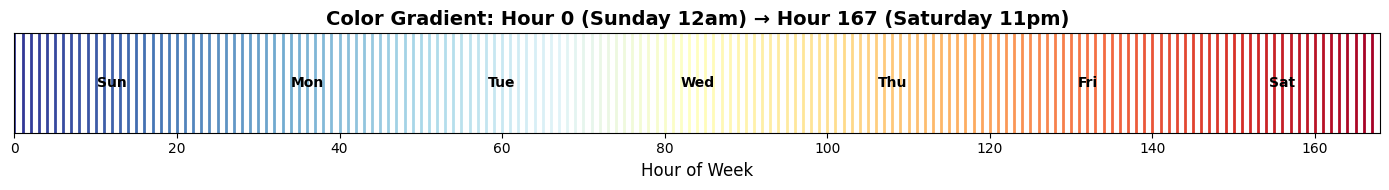

✓ Color gradient created!
  Red = Sunday
  Yellow = Mid-week
  Blue = Saturday


In [4]:
# Create color gradient: Red (Sunday) → Blue (Saturday)
# We use matplotlib's colormap to create smooth transitions

# Option 1: Red to Blue gradient
colors_red_blue = plt.cm.RdYlBu_r(np.linspace(0, 1, 168))

# Let's visualize what this gradient looks like
fig, ax = plt.subplots(1, 1, figsize=(14, 2))
for i in range(168):
    ax.axvline(i, color=colors_red_blue[i], linewidth=2)
ax.set_xlim(0, 168)
ax.set_xlabel('Hour of Week', fontsize=12)
ax.set_title('Color Gradient: Hour 0 (Sunday 12am) → Hour 167 (Saturday 11pm)', fontsize=14, fontweight='bold')
ax.set_yticks([])

# Add day labels
days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
for i, day in enumerate(days):
    ax.text(i*24 + 12, 0.5, day, ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Color gradient created!")
print("  Red = Sunday")
print("  Yellow = Mid-week")
print("  Blue = Saturday")

## Step 3: Create ONE Example Plot with Colors

Let's start with just one pair to see how it works

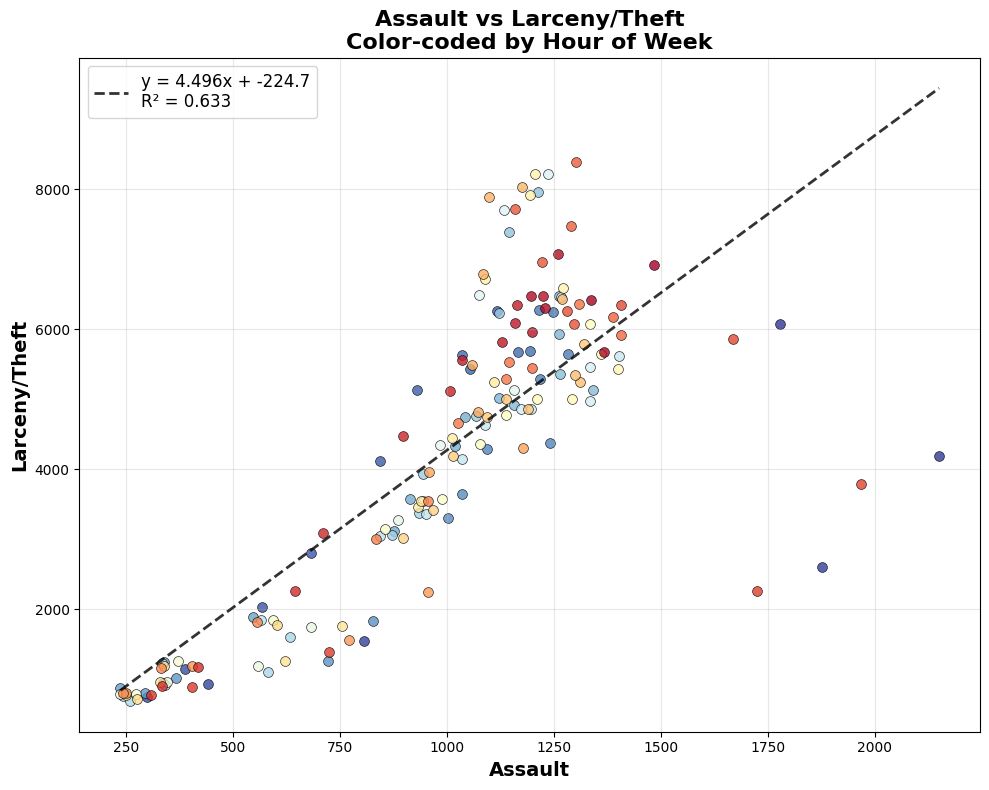


📊 What to look for:
  • Do red points (Sunday) cluster together?
  • Do blue points (Saturday) cluster together?
  • Are weekend points (blue) higher than weekday points (red/yellow)?


In [5]:
# Example: Assault vs Larceny/Theft
crime1 = 'Assault'
crime2 = 'Larceny/Theft'

x = hourly_counts[crime1]
y = hourly_counts[crime2]

# Calculate regression
a, b = linear_regression(x, y)
r2 = calculate_r_squared(x, y, a, b)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot each point with its color
for i in range(168):
    ax.scatter(x[i], y[i], color=colors_red_blue[i], s=50, alpha=0.8, edgecolors='black', linewidths=0.5)

# Add regression line
x_line = np.array([x.min(), x.max()])
y_line = a * x_line + b
ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.8, label=f'y = {a:.3f}x + {b:.1f}\nR² = {r2:.3f}')

ax.set_xlabel(crime1, fontsize=14, fontweight='bold')
ax.set_ylabel(crime2, fontsize=14, fontweight='bold')
ax.set_title(f'{crime1} vs {crime2}\nColor-coded by Hour of Week', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 What to look for:")
print("  • Do red points (Sunday) cluster together?")
print("  • Do blue points (Saturday) cluster together?")
print("  • Are weekend points (blue) higher than weekday points (red/yellow)?")

## Step 4: Create ALL 36 Plots with Color Gradient

Now let's create the full 6x6 grid with colors!

In [6]:
# Calculate regression for all pairs first
regression_results = []

for crime1, crime2 in crime_pairs:
    x = hourly_counts[crime1]
    y = hourly_counts[crime2]
    a, b = linear_regression(x, y)
    r2 = calculate_r_squared(x, y, a, b)
    regression_results.append({
        'crime1': crime1,
        'crime2': crime2,
        'slope': a,
        'intercept': b,
        'r_squared': r2
    })

results_df = pd.DataFrame(regression_results)
print(f"✓ Calculated regression for {len(regression_results)} pairs")

✓ Calculated regression for 36 pairs



✓ Created 6x6 matrix with COLOR-CODED points!
✓ Saved as: crime_pairwise_COLOR_CODED.png


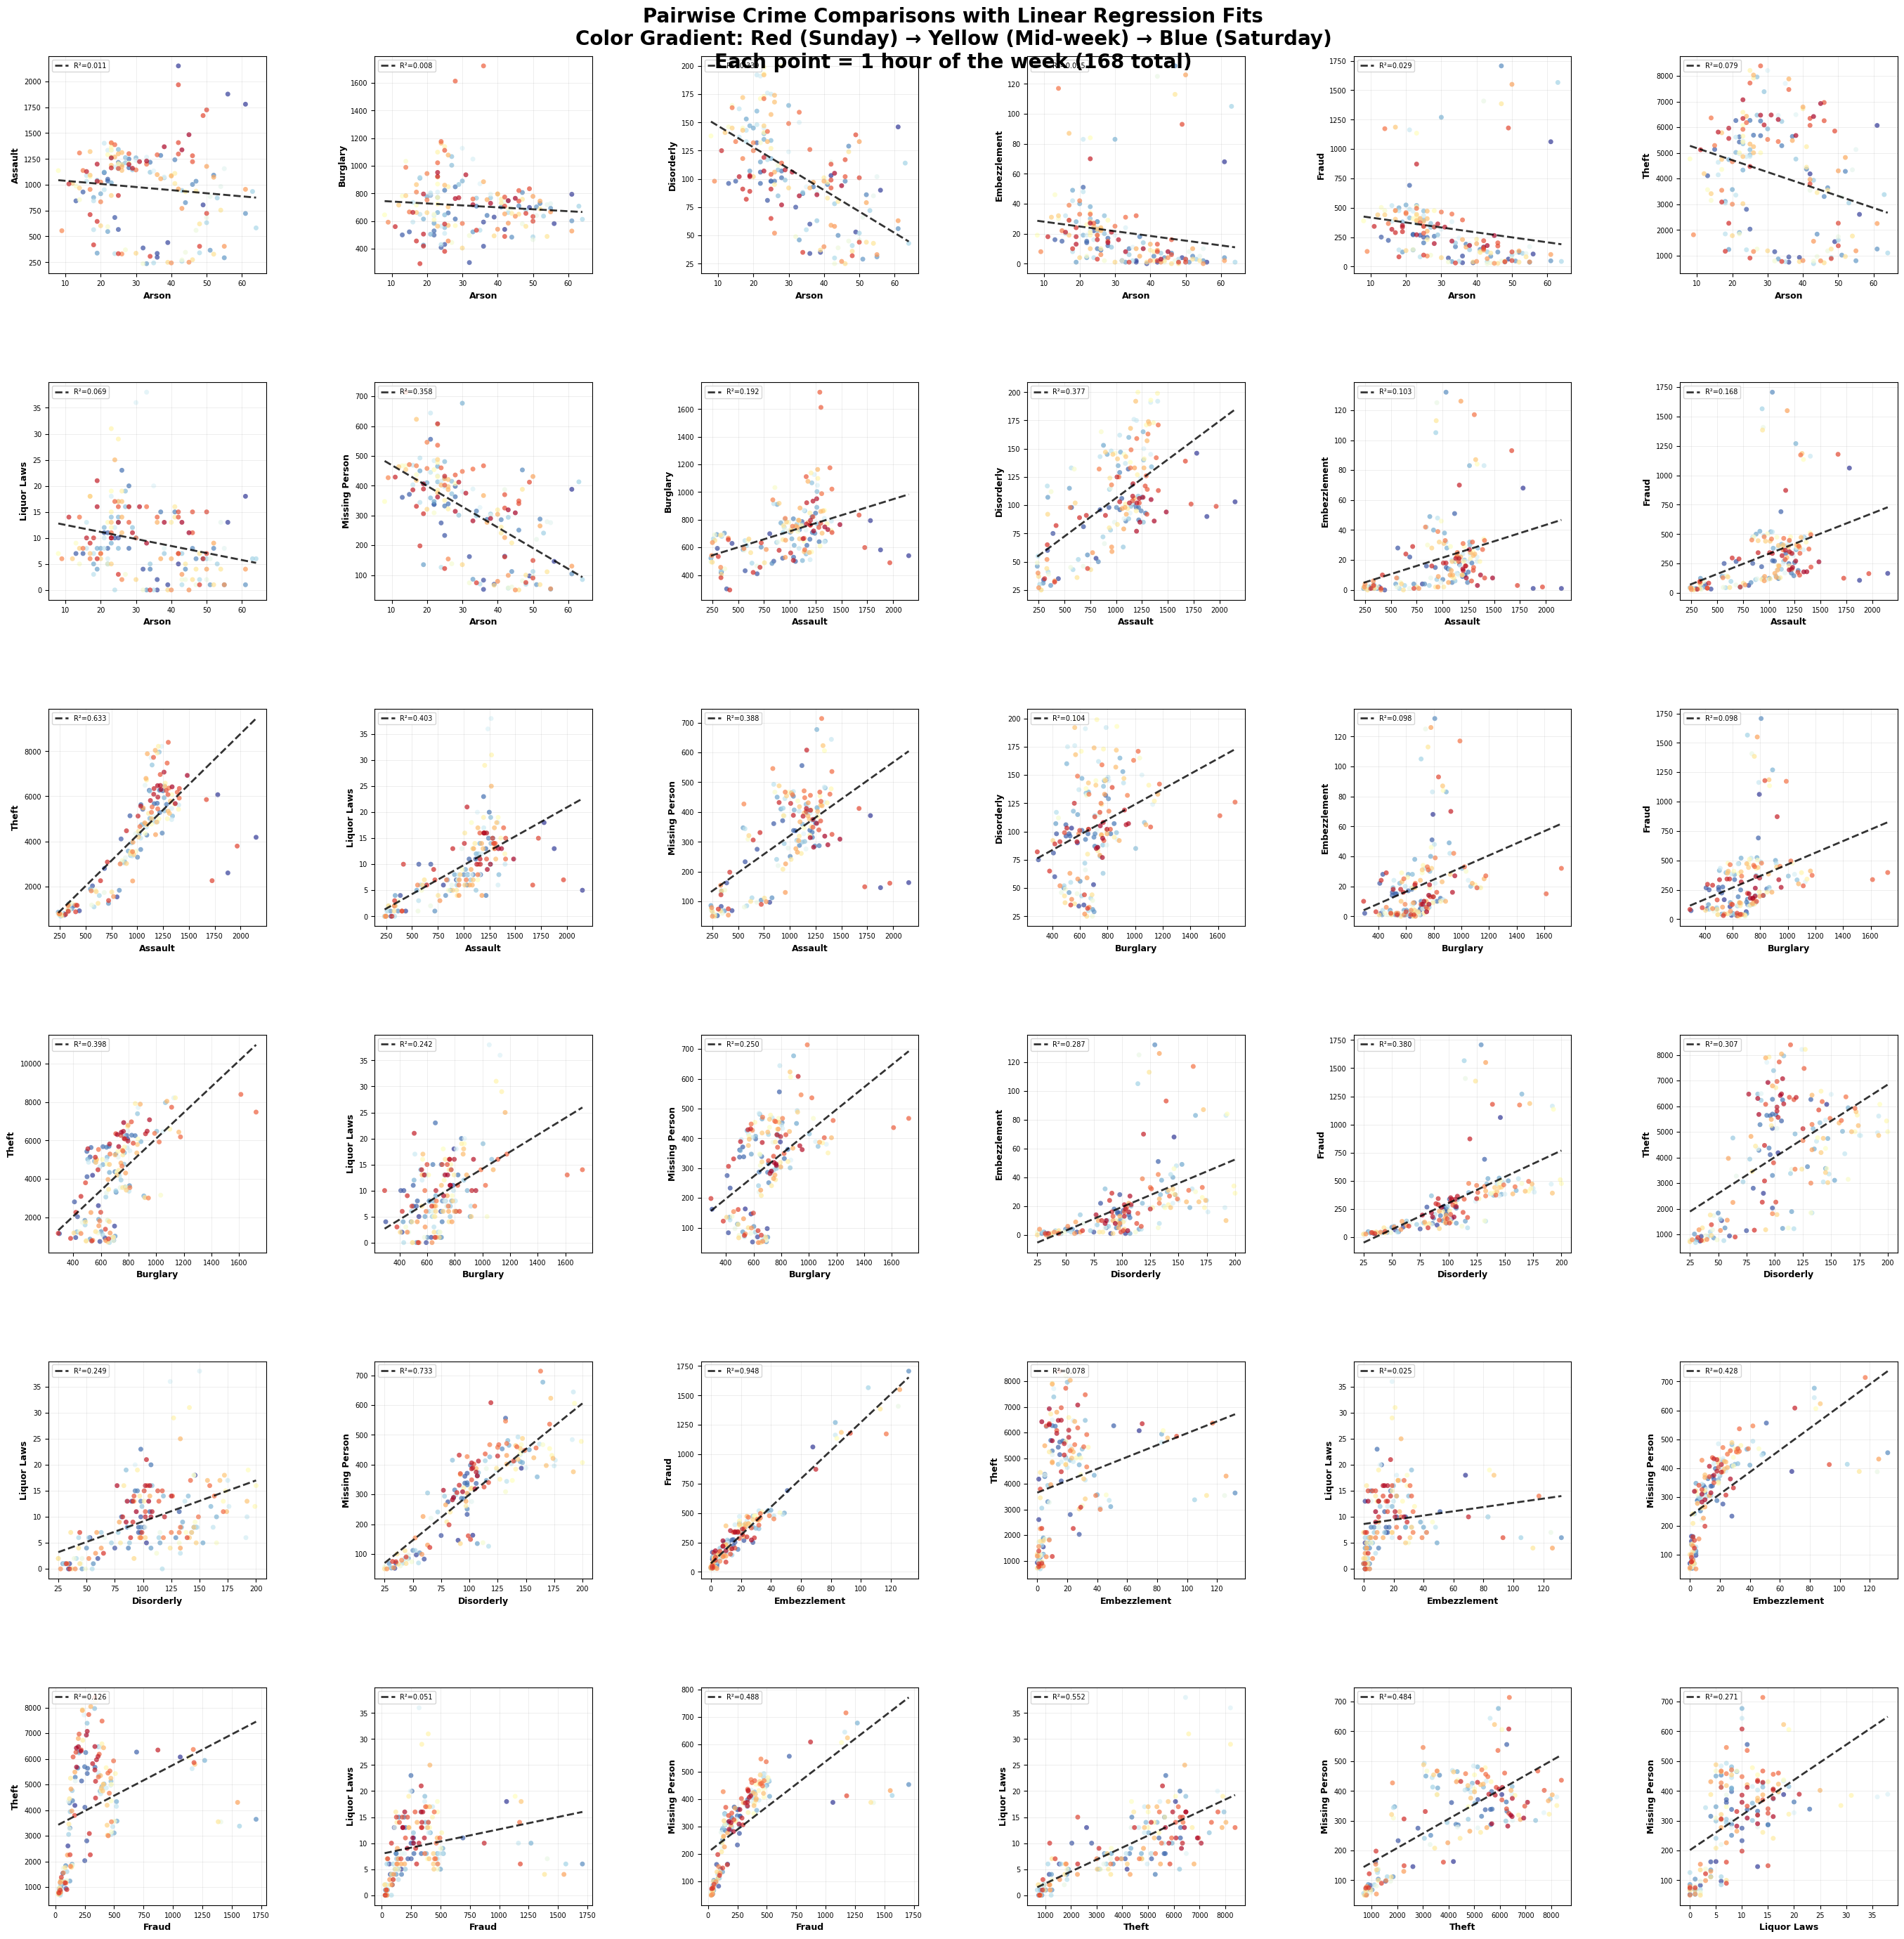

In [7]:
# Create the 6x6 grid with color-coded points
fig, axes = plt.subplots(6, 6, figsize=(28, 28))
fig.suptitle('Pairwise Crime Comparisons with Linear Regression Fits\n' +
             'Color Gradient: Red (Sunday) → Yellow (Mid-week) → Blue (Saturday)\n' +
             'Each point = 1 hour of the week (168 total)', 
             fontsize=20, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

for idx, (crime1, crime2) in enumerate(crime_pairs):
    ax = axes_flat[idx]
    
    x = hourly_counts[crime1]
    y = hourly_counts[crime2]
    
    # Get regression results
    result = results_df[(results_df['crime1'] == crime1) & 
                        (results_df['crime2'] == crime2)].iloc[0]
    a = result['slope']
    b = result['intercept']
    r2 = result['r_squared']
    
    # Plot each point with its color (THIS IS THE KEY PART!)
    for i in range(168):
        ax.scatter(x[i], y[i], color=colors_red_blue[i], s=25, alpha=0.7, edgecolors='none')
    
    # Add regression line
    x_line = np.array([x.min(), x.max()])
    y_line = a * x_line + b
    ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.8, label=f'R²={r2:.3f}')
    
    # Labels
    c1_short = crime1.replace('Larceny/Theft', 'Theft').replace('Disorderly Conduct', 'Disorderly')
    c2_short = crime2.replace('Larceny/Theft', 'Theft').replace('Disorderly Conduct', 'Disorderly')
    
    ax.set_xlabel(c1_short, fontsize=9, fontweight='bold')
    ax.set_ylabel(c2_short, fontsize=9, fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(True, alpha=0.3, linewidth=0.5)

plt.subplots_adjust(left=0.04, right=0.98, top=0.97, bottom=0.03, hspace=0.5, wspace=0.5)
plt.savefig('crime_pairwise_COLOR_CODED.png', dpi=150, bbox_inches='tight')
print("\n✓ Created 6x6 matrix with COLOR-CODED points!")
print("✓ Saved as: crime_pairwise_COLOR_CODED.png")
plt.show()

## Step 5: Interpret the Colors

Now look at your plots and answer these questions:

### Question 1: Do you see clustering by day of week?

**Look for:**
- Are red points (Sunday) grouped in one area?
- Are blue points (Saturday) grouped in another area?
- Does this tell you something about when these crimes peak?

**Your observations:**

[Write your observations here]

**Example:** If you see blue points (weekend) in the top-right corner and red points (Sunday morning) in the bottom-left, this means both crimes are HIGH on weekends and LOW on Sunday mornings.

### Question 2: Do any patterns stand out?

**Look for:**
- Pairs where weekend hours (blue) are clearly separated from weekday hours (red/yellow)
- Pairs where colors are mixed (no clear day-of-week pattern)
- Pairs where certain colors form their own cluster

**Your observations:**

[Write your observations here]

**Example:** "In the Assault vs Disorderly Conduct plot, I see that blue points (weekend) are in the upper right, suggesting both crimes peak on weekends. Red points (Sunday morning) are in the lower left, suggesting both are low then."

### Question 3: Does the color coding reveal anything new?

**Compare to the non-colored version:**
- Did you notice patterns you didn't see before?
- Does the color help you understand WHY crimes correlate?
- Can you identify specific times of week that drive the correlation?

**Your observations:**

[Write your observations here]

## Bonus: Alternative Color Schemes

Try different color gradients to see which works best!

In [ ]:
# Alternative color schemes
color_schemes = {
    'Red-Blue': plt.cm.RdYlBu_r(np.linspace(0, 1, 168)),
    'Viridis': plt.cm.viridis(np.linspace(0, 1, 168)),
    'Plasma': plt.cm.plasma(np.linspace(0, 1, 168)),
    'Cool-Warm': plt.cm.coolwarm(np.linspace(0, 1, 168)),
}

# Visualize all color schemes
fig, axes = plt.subplots(len(color_schemes), 1, figsize=(14, 8))

for idx, (name, colors) in enumerate(color_schemes.items()):
    ax = axes[idx]
    for i in range(168):
        ax.axvline(i, color=colors[i], linewidth=2)
    ax.set_xlim(0, 168)
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_yticks([])
    if idx == len(color_schemes) - 1:
        ax.set_xlabel('Hour of Week', fontsize=12)

plt.suptitle('Different Color Gradient Options', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTry changing 'colors_red_blue' to any of these in the plotting code above!")

## Summary

You've now completed Exercise 3.2 Part 2! You:

✓ Created a color gradient from red (Sunday) to blue (Saturday)
✓ Applied the gradient to all 168 points in each scatterplot
✓ Generated a 6x6 grid with color-coded points
✓ Analyzed whether certain times of week cluster together
✓ Gained new insights about temporal crime patterns

**The color coding helps you see:**
- Which hours of the week drive the correlation
- Whether weekend patterns differ from weekday patterns
- If certain times cluster in specific regions of the plot

**Next:** Move on to Exercise 3.3 to calculate R² and explore the connection to Pearson correlation!